<a href="https://colab.research.google.com/github/DiliniSew/Deep-Learning_Mini-Project/blob/Ganindu_Dev/Copy_of_Notebook_gdesh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Loading

In [ ]:
!pip install opendatasets

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import opendatasets as od

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import load_model
from tensorflow.keras.initializers import random_uniform, glorot_uniform, constant, identity
from tensorflow.keras.layers import (
    Dropout, Input, Add, Dense, Activation, BatchNormalization,
    Flatten, Conv2D, MaxPooling2D, GlobalMaxPooling2D
)
from tensorflow.keras.applications import EfficientNetV2S, MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score

In [ ]:

od.download("https://www.kaggle.com/datasets/jangedoo/utkface-new?datasetId=44109")
#{"username":"rpddsewwandi","key":"d0fb60c60bae0d7a83861a898162a399"}

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: rpddsewwandi
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new


100%|██████████| 331M/331M [00:08<00:00, 39.7MB/s]


In [ ]:

# Removed 'import random' as shuffling is no longer required

data_path = "/content/utkface-new/utkface_aligned_cropped/UTKFace"

image_paths = []
age_labels = []
gender_labels = []

if os.path.exists(data_path):
    print(f"Processing files in '{data_path}'...")
    for item in os.listdir(data_path):
        if item.endswith(".jpg") or item.endswith(".png"):
            # Filename format: age_gender_ethnicity_date.jpg.chip.jpg
            parts = item.split('_')
            if len(parts) >= 2:
                try:
                    age = int(parts[0])
                    gender = int(parts[1])
                    image_paths.append(os.path.join(data_path, item))
                    age_labels.append(age)
                    gender_labels.append(gender)
                except ValueError:
                    # Skip files with unparseable age/gender
                    continue

    print(f"Found {len(image_paths)} images.")

    # Create a DataFrame
    data = pd.DataFrame({
        'image': image_paths,
        'age': age_labels,
        'gender': gender_labels
    })

else:
    print(f"Error: Directory '{data_path}' does not exist.")


Processing files in '/content/utkface-new/utkface_aligned_cropped/UTKFace'...
Found 23708 images.


In [ ]:
print("\nFirst 5 entries of the DataFrame:")
data.head()


First 5 entries of the DataFrame:


,image,age,gender
0,/content/utkface-new/utkface_aligned_cropped/U...,24,0
1,/content/utkface-new/utkface_aligned_cropped/U...,40,1
2,/content/utkface-new/utkface_aligned_cropped/U...,38,1
3,/content/utkface-new/utkface_aligned_cropped/U...,58,1
4,/content/utkface-new/utkface_aligned_cropped/U...,48,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23708 entries, 0 to 23707
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   23708 non-null  object
 1   age     23708 non-null  int64 
 2   gender  23708 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 555.8+ KB


[Text(0.5, 1.0, 'Distribution of Age')]

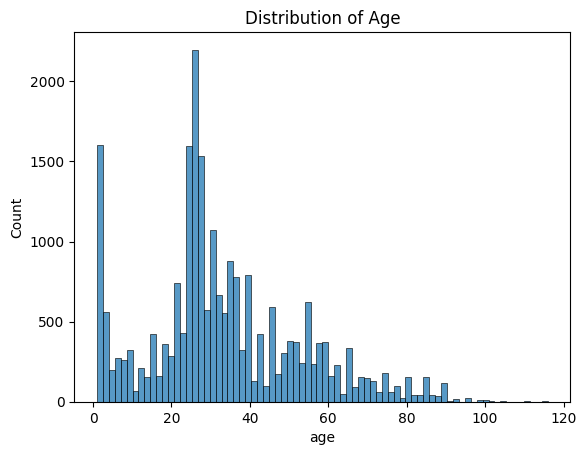

In [ ]:
sns.histplot(data.age).set(title="Distribution of Age")

[Text(0.5, 1.0, 'Distribution of Gender')]

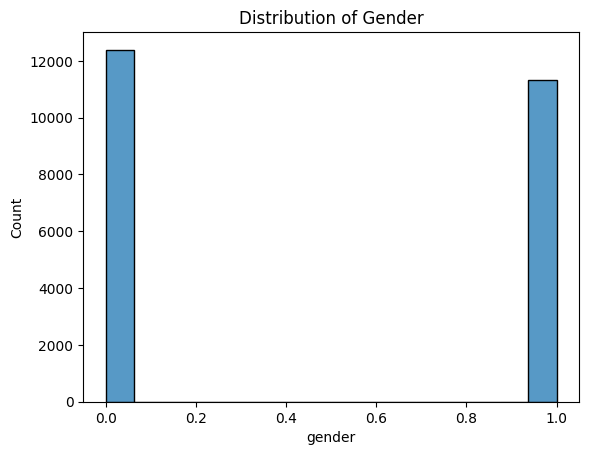

In [ ]:
# Plotting the distribution of 'gender'
sns.histplot(data.gender).set(title="Distribution of Gender")

#Data Preprocessing

In [ ]:
# Create a copy of the original DataFrame
data_shuffled = data.copy()

# Shuffle the copied DataFrame
data_shuffled = data_shuffled.sample(frac=1).reset_index(drop=True)

print("First 5 entries of the shuffled DataFrame:")
print(data_shuffled.head())


First 5 entries of the shuffled DataFrame:
                                               image  age  gender
0  /content/utkface-new/utkface_aligned_cropped/U...   45       0
1  /content/utkface-new/utkface_aligned_cropped/U...    2       1
2  /content/utkface-new/utkface_aligned_cropped/U...   40       1
3  /content/utkface-new/utkface_aligned_cropped/U...   80       1
4  /content/utkface-new/utkface_aligned_cropped/U...   26       0


In [ ]:
print("Null values in the shuffled DataFrame:")
print(data_shuffled.isnull().sum())


Null values in the shuffled DataFrame:
image     0
age       0
gender    0
dtype: int64


# Data Analysis
Analyze the 'age' and 'gender' columns in the `data_shuffled` DataFrame to identify and visualize outliers or inconsistencies, specifically by examining the distribution of age, verifying gender values, and checking for unusual age-gender combinations.

## Analyze Age Distribution for Outliers




Descriptive statistics for 'age' column:
count    23708.000000
mean        33.303484
std         19.886112
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64


[Text(0.5, 1.0, 'Box Plot of Age Distribution with Outliers')]

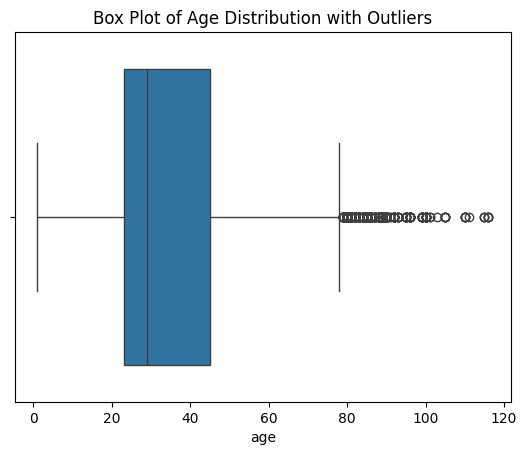

In [ ]:
print("Descriptive statistics for 'age' column:")
print(data_shuffled['age'].describe())

# Create a box plot of the 'age' column to visualize outliers
sns.boxplot(x=data_shuffled['age']).set(title="Box Plot of Age Distribution with Outliers")

## Check for Inconsistent Gender Values





To verify that the 'gender' column only contains binary values (0 or 1).

In [ ]:
print("Unique values in 'gender' column:")
print(data_shuffled['gender'].unique())

print("\nValue counts for 'gender' column:")
print(data_shuffled['gender'].value_counts())

Unique values in 'gender' column:
[0 1]

Value counts for 'gender' column:
gender
0    12391
1    11317
Name: count, dtype: int64


## Identify Extreme Age-Gender Combinations

Investigate if there are any data points with age and gender combinations that seem highly improbable or inconsistent (e.g., extreme ages associated with specific gender representations that could indicate data errors).


In [ ]:
print("Descriptive statistics for 'age' grouped by 'gender':")
print(data_shuffled.groupby('gender')['age'].describe())

Descriptive statistics for 'age' grouped by 'gender':
          count       mean        std  min   25%   50%   75%    max
gender                                                             
0       12391.0  35.695666  19.705223  1.0  25.0  34.0  50.0  110.0
1       11317.0  30.684280  19.753650  1.0  21.0  26.0  37.0  116.0


To visually compare the age distributions for each gender and identify potential outliers, create side-by-side box plots of the 'age' column, separated by 'gender'.



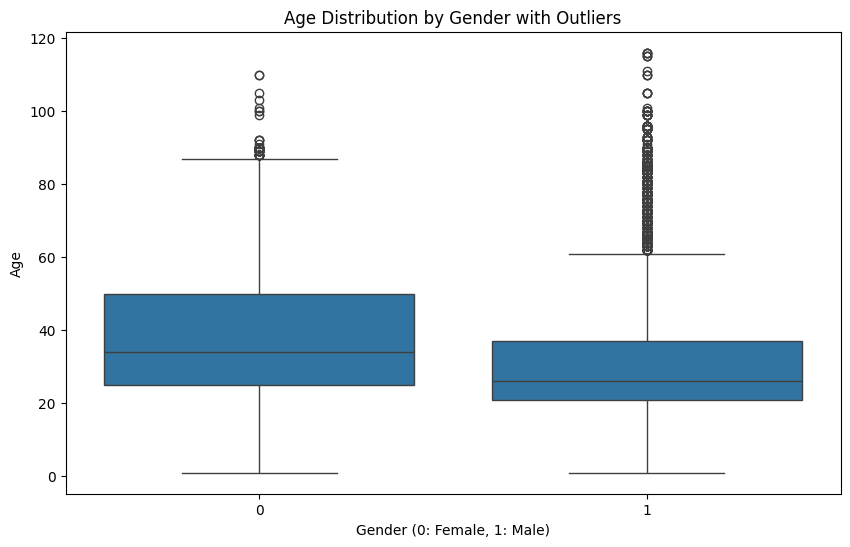

In [ ]:


plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='age', data=data_shuffled)
plt.title('Age Distribution by Gender with Outliers')
plt.xlabel('Gender (0: Female, 1: Male)')
plt.ylabel('Age')
plt.show()

## Summary:

The analysis successfully identified and visualized potential outliers and inconsistencies in the 'age' and 'gender' columns.
*   **Age Distribution:** The 'age' column shows a wide range (1 to 116 years) with a right-skewed distribution, and a maximum age of 116 indicating potential outliers at the upper end.
*   **Gender Values:** The 'gender' column is consistent, containing only the expected binary values (0 and 1).
*   **Age-Gender Combinations:** While both gender groups exhibit a wide age range (up to 110 for gender 0 and 116 for gender 1), no immediately impossible or highly inconsistent age-gender combinations were identified.

### Data Analysis Key Findings
*   The 'age' column in `data_shuffled` has a mean of 33.30 and a median of 29.00, suggesting a right-skewed distribution.
*   A wide age range is observed, from a minimum of 1 year to a maximum of 116 years, with the maximum age potentially indicating outliers.
*   The 'gender' column contains only two unique values: 0 (12,391 occurrences) and 1 (11,317 occurrences), confirming consistency and the absence of unexpected entries.
*   When grouped by gender, the mean age for gender 0 is approximately 35.7 years (range 1-110), and for gender 1 is approximately 30.7 years (range 1-116).
*   No impossible age values (e.g., negative ages) or highly improbable age-gender combinations were found in the dataset, although the upper age limits of 110 and 116 are at the very high end of human lifespan.



In [ ]:
image_paths, age_labels, gender_labels = [], [], []
AGE_MAX = 80.0

for item in os.listdir(data_path):
    if item.endswith(".jpg") or item.endswith(".png"):
        parts = item.split('_')
        if len(parts) >= 2:
            try:
                age = int(parts[0])
                gender = int(parts[1])
                if 1 <= age <= AGE_MAX and gender in [0, 1]:
                    image_paths.append(os.path.join(data_path, item))
                    age_labels.append(age)
                    gender_labels.append(gender)
            except ValueError:
                continue

data = pd.DataFrame({'image': image_paths, 'age': age_labels, 'gender': gender_labels})
data['age_norm'] = data['age'] / AGE_MAX
print(f"Total valid images: {len(data)}")

Total valid images: 23168


In [ ]:
# Shuffle
data = data.sample(frac=1, random_state=42).reset_index(drop=True)



In [ ]:
# Downsample overrepresented ages
max_samples = int(data['age'].value_counts().quantile(0.75))
downsampled = []
for age in data['age'].unique():
    group = data[data['age'] == age]
    downsampled.append(group.sample(n=min(len(group), max_samples), random_state=42))

data_final = pd.concat(downsampled).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"After downsampling: {len(data_final)}")


After downsampling: 16579


[Text(0.5, 1.0, 'Distribution of Age after Downsampling')]

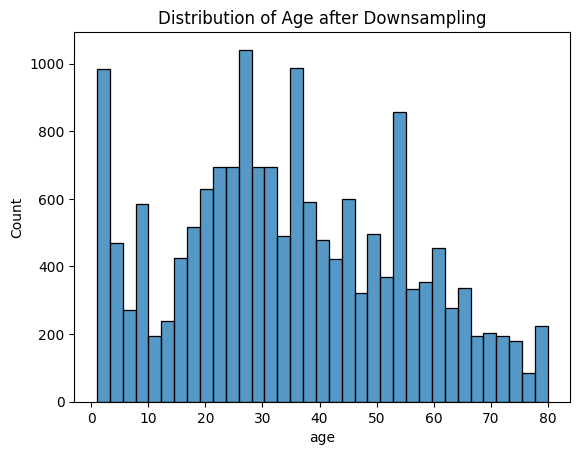

In [ ]:
#DISTRIBUTION after downsampling
sns.histplot(data_final.age).set(title="Distribution of Age after Downsampling")


In [ ]:
# Split — 75% train, 10% val, 15% test
train_df, test_df = train_test_split(data_final, test_size=0.15, random_state=42)
train_df, val_df  = train_test_split(train_df,  test_size=0.12, random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 12400 | Val: 1692 | Test: 2487


In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

def load_and_preprocess(path, age, gender):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, {'age_output': age, 'gender_output': gender}

def augment(img, labels):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, labels

def make_dataset(df, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df['image'].values,
        df['age'].values.astype(np.float32),
        df['gender'].values.astype(np.float32)
    ))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, augment_data=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

In [ ]:
from tensorflow.keras import regularizers

def build_model():
    base = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    age_x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    age_x = layers.Dropout(0.3)(age_x)
    age_output = layers.Dense(1, activation='relu', name='age_output')(age_x)

    gender_x = layers.Dense(64, activation='relu')(x)
    gender_output = layers.Dense(1, activation='sigmoid', name='gender_output')(gender_x)

    return Model(inputs, [age_output, gender_output]), base

model, base_model = build_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    655,872 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     65,664 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     32,832 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 1)         │        129 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │         65 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,014,594 (11.50 MB)

 Trainable params: 755,586 (2.88 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

In [ ]:
model.compile(
    optimizer=Adam(1e-3),
    loss={
        'age_output': 'mae',
        'gender_output': 'binary_crossentropy'
    },
    loss_weights={'age_output': 0.02, 'gender_output': 1.0},
    metrics={'age_output': 'mae', 'gender_output': 'accuracy'}
)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_age_output_mae', patience=5, restore_best_weights=True, mode='min'),
        ReduceLROnPlateau(monitor='val_age_output_mae', factor=0.5, patience=2, mode='min'),
        ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_age_output_mae', mode='min')
    ]
)

Epoch 1/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 87s 164ms/step - age_output_loss: 14.7221 - age_output_mae: 14.7266 - gender_output_accuracy: 0.8024 - gender_output_loss: 0.4310 - loss: 0.7450 - val_age_output_loss: 10.1101 - val_age_output_mae: 10.1037 - val_gender_output_accuracy: 0.8363 - val_gender_output_loss: 0.3557 - val_loss: 0.5749 - learning_rate: 0.0010
Epoch 2/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - age_output_loss: 10.6512 - age_output_mae: 10.6534 - gender_output_accuracy: 0.8352 - gender_output_loss: 0.3610 - loss: 0.5903 - val_age_output_loss: 9.4320 - val_age_output_mae: 9.4274 - val_gender_output_accuracy: 0.8457 - val_gender_output_loss: 0.3319 - val_loss: 0.5348 - learning_rate: 0.0010
Epoch 3/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - age_output_loss: 10.0833 - age_output_mae: 10.0855 - gender_output_accuracy: 0.8515 - gender_output_loss: 0.3336 - loss: 0.5493 - val_age_output_loss: 9.0672 - val_age_output_mae: 9.0636 - val_gender_output_accuracy: 0.8517 - val

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(1e-5),
    loss={
        'age_output': 'mae',
        'gender_output': 'binary_crossentropy'
    },
    loss_weights={'age_output': 0.02, 'gender_output': 1.0},
    metrics={'age_output': 'mae', 'gender_output': 'accuracy'}
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        EarlyStopping(monitor='val_age_output_mae', patience=7, restore_best_weights=True, mode='min'),
        ReduceLROnPlateau(monitor='val_age_output_mae', factor=0.3, patience=3, mode='min'),
        ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_age_output_mae', mode='min')
    ]
)

Epoch 1/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 57s 109ms/step - age_output_loss: 8.6496 - age_output_mae: 8.6498 - gender_output_accuracy: 0.9358 - gender_output_loss: 0.1626 - loss: 0.3417 - val_age_output_loss: 8.5851 - val_age_output_mae: 8.5834 - val_gender_output_accuracy: 0.8434 - val_gender_output_loss: 0.4157 - val_loss: 0.5931 - learning_rate: 1.0000e-05
Epoch 2/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - age_output_loss: 8.5722 - age_output_mae: 8.5702 - gender_output_accuracy: 0.9413 - gender_output_loss: 0.1478 - loss: 0.3253 - val_age_output_loss: 8.3723 - val_age_output_mae: 8.3701 - val_gender_output_accuracy: 0.8593 - val_gender_output_loss: 0.3837 - val_loss: 0.5566 - learning_rate: 1.0000e-05
Epoch 3/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - age_output_loss: 8.5422 - age_output_mae: 8.5430 - gender_output_accuracy: 0.9494 - gender_output_loss: 0.1321 - loss: 0.3090 - val_age_output_loss: 8.2825 - val_age_output_mae: 8.2800 - val_gender_output_accuracy: 0.8552 - val

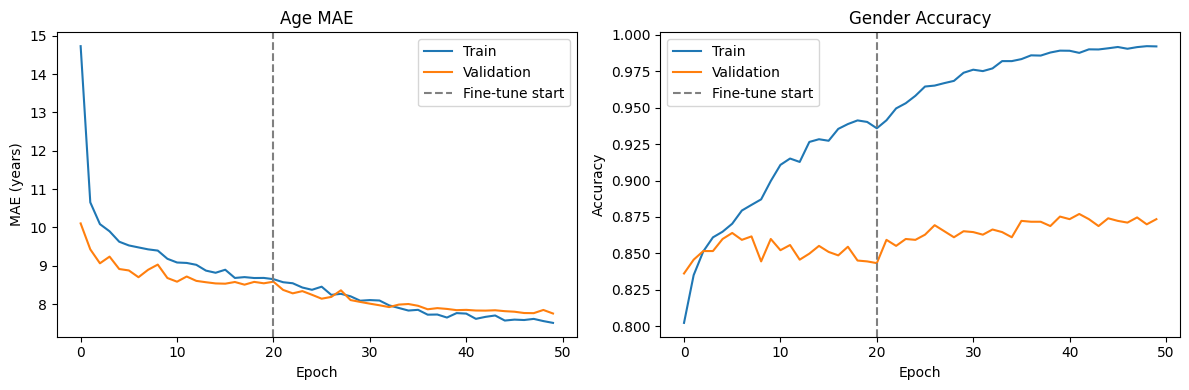

In [ ]:
def plot_history(h1, h2, metric, title, ylabel):
    full_train = h1.history[metric] + h2.history[metric]
    full_val   = h1.history[f'val_{metric}'] + h2.history[f'val_{metric}']
    split_pt   = len(h1.history[metric])

    plt.plot(full_train, label='Train')
    plt.plot(full_val,   label='Validation')
    plt.axvline(split_pt, color='gray', linestyle='--', label='Fine-tune start')
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel(ylabel); plt.legend()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plot_history(history1, history2, 'age_output_mae', 'Age MAE', 'MAE (years)')
plt.subplot(1, 2, 2)
plot_history(history1, history2, 'gender_output_accuracy', 'Gender Accuracy', 'Accuracy')
plt.tight_layout(); plt.show()

In [ ]:
model = tf.keras.models.load_model('best_model.keras')

age_true, age_pred_all, gender_true, gender_pred_raw = [], [], [], []

for imgs, labels in test_ds:
    ap, gp = model.predict(imgs, verbose=0)
    age_true.extend(labels['age_output'].numpy())
    age_pred_all.extend(ap.flatten())
    gender_true.extend(labels['gender_output'].numpy())
    gender_pred_raw.extend(gp.flatten())

age_true     = np.array(age_true)
age_pred_all = np.clip(np.array(age_pred_all), 1, 80)
gender_true  = np.array(gender_true).astype(int)
gender_pred  = (np.array(gender_pred_raw) >= 0.5).astype(int)

print("✓ Model loaded and predictions generated")
print(f"  Total samples: {len(age_true)}")

✓ Model loaded and predictions generated
  Total samples: 2487


In [ ]:
# CELL 2: Calculate age regression metrics
mae     = mean_absolute_error(age_true, age_pred_all)
rmse    = np.sqrt(mean_squared_error(age_true, age_pred_all))
r2      = r2_score(age_true, age_pred_all)
within5 = np.mean(np.abs(age_true - age_pred_all) <= 5) * 100
within10= np.mean(np.abs(age_true - age_pred_all) <= 10) * 100

print("=" * 45)
print("AGE REGRESSION METRICS")
print("=" * 45)
print(f"  MAE          : {mae:.2f} years")
print(f"  RMSE         : {rmse:.2f} years")
print(f"  R2           : {r2:.4f}")
print(f"  Within ±5yr  : {within5:.1f}%")
print(f"  Within ±10yr : {within10:.1f}%")

AGE REGRESSION METRICS
  MAE          : 7.67 years
  RMSE         : 10.43 years
  R2           : 0.7214
  Within ±5yr  : 45.7%
  Within ±10yr : 71.8%


In [ ]:
# CELL 3: Gender classification metrics
print("\n" + "=" * 45)
print("GENDER CLASSIFICATION METRICS")
print("=" * 45)
print(classification_report(gender_true, gender_pred, target_names=['Male', 'Female']))


GENDER CLASSIFICATION METRICS
              precision    recall  f1-score   support

        Male       0.91      0.89      0.90      1342
      Female       0.87      0.90      0.89      1145

    accuracy                           0.89      2487
   macro avg       0.89      0.89      0.89      2487
weighted avg       0.89      0.89      0.89      2487



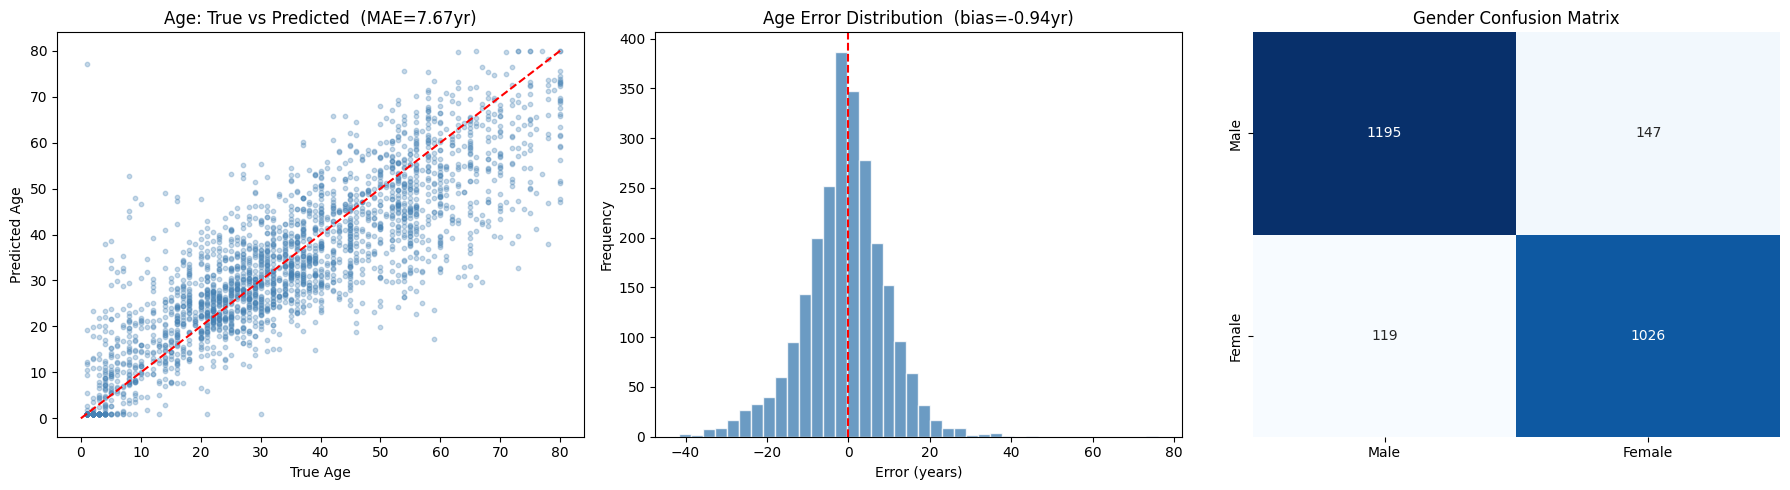

In [ ]:
# CELL 4: Age scatter + error distribution + confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(age_true, age_pred_all, alpha=0.3, s=10, c='steelblue')
axes[0].plot([0, 80], [0, 80], 'r--', lw=1.5)
axes[0].set_xlabel("True Age")
axes[0].set_ylabel("Predicted Age")
axes[0].set_title(f"Age: True vs Predicted  (MAE={mae:.2f}yr)")

errors = age_pred_all - age_true
axes[1].hist(errors, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_title(f"Age Error Distribution  (bias={errors.mean():.2f}yr)")
axes[1].set_xlabel("Error (years)")
axes[1].set_ylabel("Frequency")

cm = confusion_matrix(gender_true, gender_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2],
            xticklabels=['Male','Female'], yticklabels=['Male','Female'],
            cmap='Blues', cbar=False)
axes[2].set_title("Gender Confusion Matrix")

plt.tight_layout()
plt.show()


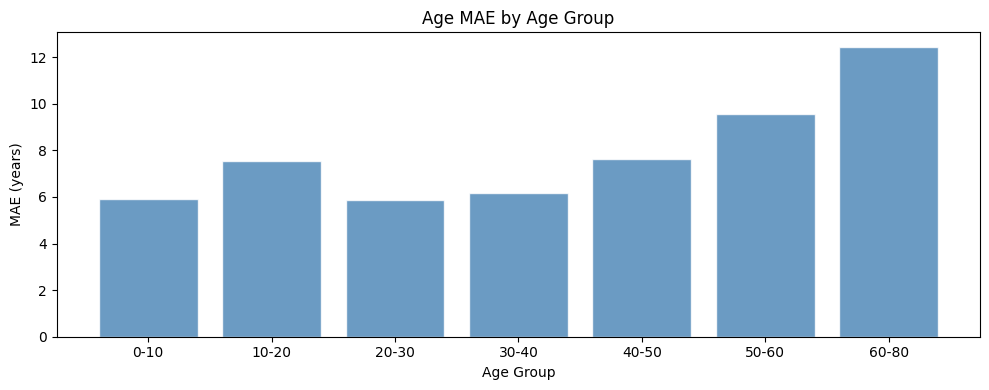

In [ ]:
# CELL 5: Age MAE by age group
fig2, ax = plt.subplots(figsize=(10, 4))

bins = [0, 10, 20, 30, 40, 50, 60, 80]
bin_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-80']
bin_idx = np.digitize(age_true, bins) - 1

group_mae = [mean_absolute_error(age_true[bin_idx==i], age_pred_all[bin_idx==i])
             if (bin_idx==i).sum() > 0 else 0 for i in range(len(bin_labels))]

ax.bar(bin_labels, group_mae, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xlabel("Age Group")
ax.set_ylabel("MAE (years)")
ax.set_title("Age MAE by Age Group")

plt.tight_layout()
plt.show()

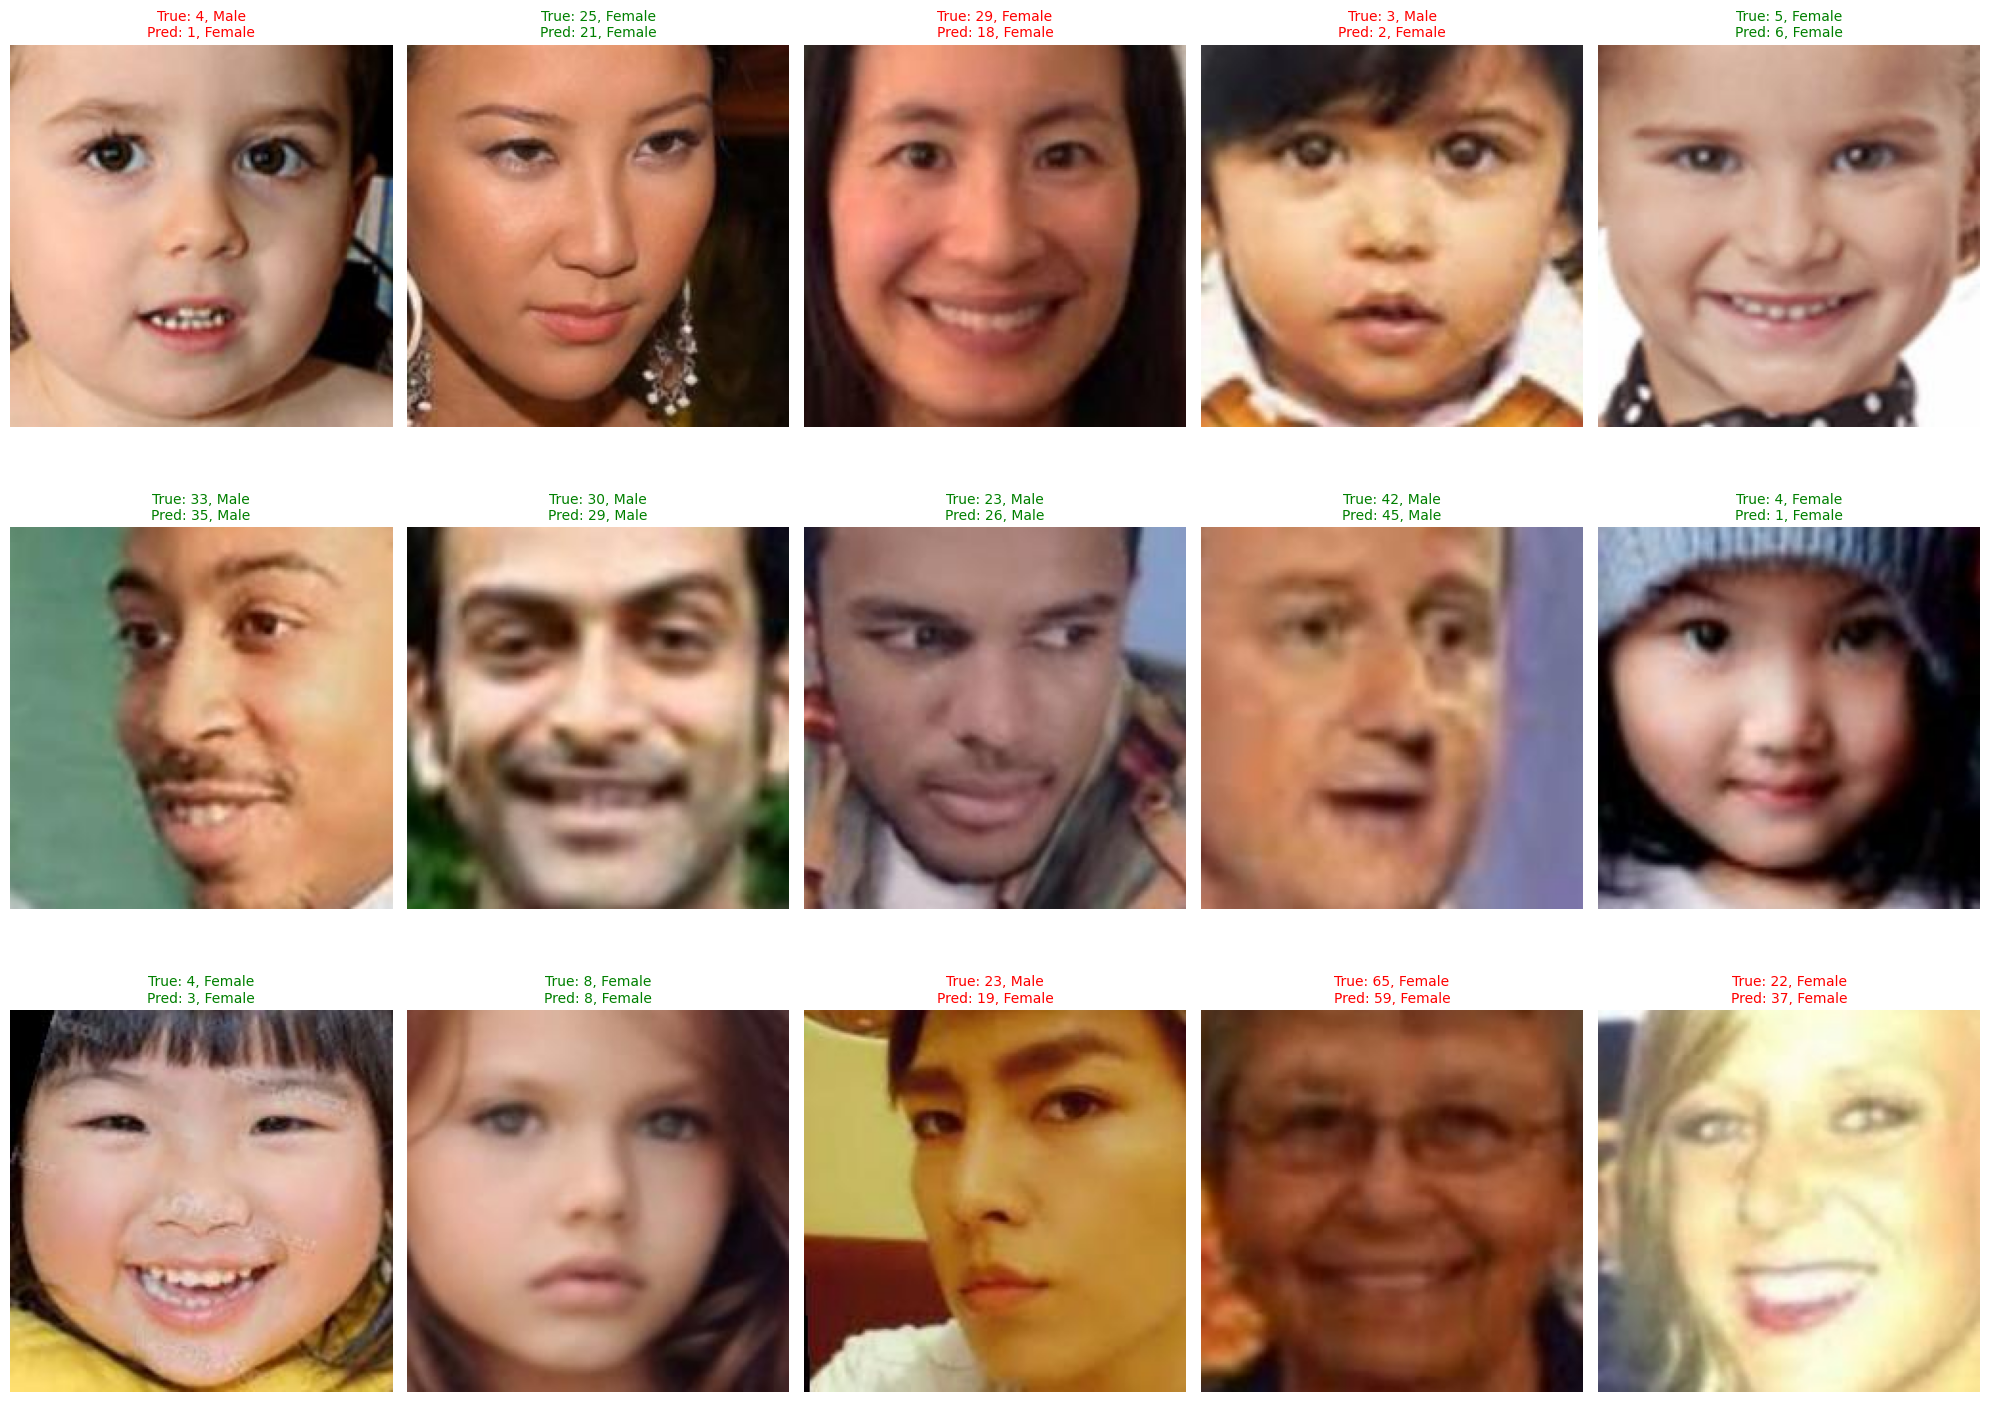

In [ ]:
plt.figure(figsize=(20, 15))

# Mapping for gender display
gender_map = {0: 'Male', 1: 'Female'}

# Generate 15 random indices from the test set
import random
random_indices = random.sample(range(len(test_df)), 15)

# Display 15 random images in a 3x5 grid
for i, idx in enumerate(random_indices):
    plt.subplot(3, 5, i + 1)

    # Load and show image
    img_path = test_df.iloc[idx]['image']
    img = load_img(img_path)
    plt.imshow(img)

    true_age = int(age_true[idx])
    pred_age = int(np.round(age_pred_all[idx]))
    true_gen = gender_map.get(gender_true[idx], 'Unknown')
    pred_gen = gender_map.get(gender_pred[idx], 'Unknown')

    title_color = 'green' if (true_gen == pred_gen and abs(true_age - pred_age) <= 5) else 'red'

    plt.title(f"True: {true_age}, {true_gen}\nPred: {pred_age}, {pred_gen}", color=title_color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

# Download the best model saved during training
files.download('best_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>